# ImageNet100 用の DeepInversion & 特徴量の可視化ノートブック


In [1]:
import os
import sys
import numpy as np
import json
import random
import collections


import torch
import torch.optim as optim
import torchvision.utils as vutils

import torch.nn as nn
import torch.nn.functional as F



In [2]:
# 使用するgpuを指定
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

## パスの設定

In [3]:
# ベース部分のパス
ckpt_path = "/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/checkpoint"


# imagenet100のbaseline用パス
base_imnet100_path = "baseline/imagenet100"

# baseline
method = "baseline"
baseline_path = os.path.join(ckpt_path, method, base_imnet100_path, "50/5/10_10_0_0_0")

## 色々と設定

In [4]:

# プロジェクト root を sys.path に追加
project_root = "/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL"
sys.path.append(project_root)


from utils import factory
import models


# --- 1) 設定を記述した jsonファイル の内容を読む ---
with open(os.path.join(project_root, "exps", "BASELINE", "imnet100.json")) as f:
    args = json.load(f)

args["device"] = ["0"]            # 必要に応じて
# args["model_name"] = "baseline" 


# --- 2) learner とネットワークの作成 ---
learner = factory.get_model(args["model_name"], args)
net = learner._network


# --- 3) checkpoint の読み込み ---
ckpt_dir = baseline_path
print("ckpt_dir: ", ckpt_dir)
ckpt_file = os.path.join(ckpt_dir, "phase0.pkl")       # 読み込むモデルの指定

ckpt = torch.load(ckpt_file, map_location="cuda:0")
state_dict = ckpt["model_state_dict"]
print(state_dict.keys())

# fc の出力次元を checkpoint から取得
num_outputs = state_dict["fc.weight"].shape[0]
print("num_outputs: ", num_outputs)

# fc層の出力次元数を変更
net.update_fc(num_outputs)

# state_dict の読み込み
net.load_state_dict(state_dict)

net.cuda().eval()

# 忘却クラスや class_order を取り出す
forget_classes = ckpt.get("forget_classes", None)
class_order = ckpt.get("_class_order", None)
print(class_order)

ckpt_dir:  /home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/checkpoint/baseline/baseline/imagenet100/50/5/10_10_0_0_0


<ipython-input-4-68a8c6da2adc>:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_file, map_location="cuda:0")


odict_keys(['convnet.conv1.0.weight', 'convnet.conv1.1.weight', 'convnet.conv1.1.bias', 'convnet.conv1.1.running_mean', 'convnet.conv1.1.running_var', 'convnet.conv1.1.num_batches_tracked', 'convnet.layer1.0.conv1.weight', 'convnet.layer1.0.bn1.weight', 'convnet.layer1.0.bn1.bias', 'convnet.layer1.0.bn1.running_mean', 'convnet.layer1.0.bn1.running_var', 'convnet.layer1.0.bn1.num_batches_tracked', 'convnet.layer1.0.conv2.weight', 'convnet.layer1.0.bn2.weight', 'convnet.layer1.0.bn2.bias', 'convnet.layer1.0.bn2.running_mean', 'convnet.layer1.0.bn2.running_var', 'convnet.layer1.0.bn2.num_batches_tracked', 'convnet.layer1.1.conv1.weight', 'convnet.layer1.1.bn1.weight', 'convnet.layer1.1.bn1.bias', 'convnet.layer1.1.bn1.running_mean', 'convnet.layer1.1.bn1.running_var', 'convnet.layer1.1.bn1.num_batches_tracked', 'convnet.layer1.1.conv2.weight', 'convnet.layer1.1.bn2.weight', 'convnet.layer1.1.bn2.bias', 'convnet.layer1.1.bn2.running_mean', 'convnet.layer1.1.bn2.running_var', 'convnet.layer

## Hookの設定

In [5]:
class DeepInversionFeatureHook():
    '''
    Implementation of the forward hook to track feature statistics and compute a loss on them.
    Will compute mean and variance, and will use l2 as a loss
    '''

    def __init__(self, module):
        self.hook = module.register_forward_hook(self.hook_fn)


    def hook_fn(self, module, input, output):
        # hook co compute deepinversion's feature distribution regularization
        nch = input[0].shape[1]

        mean = input[0].mean([0, 2, 3])
        var = input[0].permute(1, 0, 2, 3).contiguous().view([nch, -1]).var(1, unbiased=False)

        # forcing mean and variance to match between two distributions
        # other ways might work better, e.g. KL divergence
        r_feature = torch.norm(module.running_var.data.type(var.type()) - var, 2) + torch.norm(
            module.running_mean.data.type(var.type()) - mean, 2)

        self.r_feature = r_feature
        # must have no output

    def close(self):
        self.hook.remove()


## 最適化対象の準備など

In [6]:
# exp_name = args.exp_name
# # final images will be stored here:
# adi_data_path = "./final_images/%s"%exp_name
# # temporal data and generations will be stored here
# exp_name = "generations/%s"%exp_name

iterations = 2000
start_noise = True
# args.detach_student = False

resolution = 224
bs = 120
jitter = 30

setting_id = 0
data_type = torch.float

parameters = dict()
parameters["resolution"] = 224
parameters["random_label"] = False
parameters["start_noise"] = True
parameters["detach_student"] = False
parameters["do_flip"] = True

parameters["store_best_images"] = True

criterion = nn.CrossEntropyLoss()


coefficients = dict()


# 通常ver
coefficients["r_feature"] = 0.01   # github由来
coefficients["first_bn_multiplier"] = 10
coefficients["tv_l1"] = 0.0
coefficients["tv_l2"] = 0.0001
coefficients["l2"] = 0.00001
coefficients["lr"] = 0.25
coefficients["main_loss_multiplier"] = 1.0
coefficients["adi_scale"] = 0.0
coefficients["exp_descr"] = "debug_imnet100_v1"

# v1 から r_feature を少し増加
# coefficients["r_feature"] = 0.03
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v2"

# v2 から r_feature を少し増加
# coefficients["r_feature"] = 0.05
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v3"

# v3 から r_feature を少し増加
# coefficients["r_feature"] = 0.05
# coefficients["first_bn_multiplier"] = 15
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v4"

# v4 から r_feature を少し増加
# coefficients["r_feature"] = 0.1
# coefficients["first_bn_multiplier"] = 20
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v5"

# v5 から r_feature を少し増加
# coefficients["r_feature"] = 0.2
# coefficients["first_bn_multiplier"] = 20
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v6"

# 1からmain_loss_multiplierを少し増加
# coefficients["r_feature"] = 0.01
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.2
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v7"

# 7からmain_loss_multiplierを少し増加
# coefficients["r_feature"] = 0.01
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.5
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v9"

# 9からmain_loss_multiplierを少し増加
# coefficients["r_feature"] = 0.01
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 2.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v10"

# 10からmain_loss_multiplierを少し増加
# coefficients["r_feature"] = 0.01
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 2.2
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v11"

# 11からmain_loss_multiplierを少し増加
# coefficients["r_feature"] = 0.01
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 2.5
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v12"

# 12からmain_loss_multiplierを少し増加
# coefficients["r_feature"] = 0.01
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 2.5
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v12"

# 13からmain_loss_multiplierを少し増加
# coefficients["r_feature"] = 0.01
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 3.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v13"

# 14からmain_loss_multiplierを大きく増加
# coefficients["r_feature"] = 0.01
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 5.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v14"

# 15からr_featureを少し増加
# coefficients["r_feature"] = 0.03
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 5.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v15"

# 15からtv_l2を少し減少
# coefficients["r_feature"] = 0.03
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.00005
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 5.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v16"

# 15からtv_l2を強める
# coefficients["r_feature"] = 0.03
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 5.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v17"

# 17からr_featureを強める
# coefficients["r_feature"] = 0.07
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 5.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v19"


# ver1 から r_feature を少し増加
# coefficients["r_feature"] = 0.02   # github由来
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v20"

# ver1 から tv_l2 を少し増加
# coefficients["r_feature"] = 0.01   # github由来
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0003
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v21"

# ver1 から l2 を少し増加
# coefficients["r_feature"] = 0.01   # github由来
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.0001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v22"

# ver21 から tv_l2 を少し増加
# coefficients["r_feature"] = 0.01   # github由来
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.001
# coefficients["l2"] = 0.0001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v23"

# ver22 から r_feature を少し増加
# coefficients["r_feature"] = 0.02   # github由来
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.0001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 1.0
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v24"

# coefficients["r_feature"] = 0.01   # github由来
# coefficients["first_bn_multiplier"] = 10
# coefficients["tv_l1"] = 0.0
# coefficients["tv_l2"] = 0.0001
# coefficients["l2"] = 0.00001
# coefficients["lr"] = 0.25
# coefficients["main_loss_multiplier"] = 0.8
# coefficients["adi_scale"] = 0.0
# coefficients["exp_descr"] = "debug_imnet100_v25"

network_output_function = lambda x: x


prefix = "runs/data_generation_di_imnet_0-9/"+coefficients["exp_descr"]+"/"

for create_folder in [prefix, prefix+"/best_images/"]:
    if not os.path.exists(create_folder):
        os.makedirs(create_folder)

In [7]:
def lr_policy(lr_fn):
    def _alr(optimizer, iteration, epoch):
        lr = lr_fn(iteration, epoch)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

    return _alr


def lr_cosine_policy(base_lr, warmup_length, epochs):
    def _lr_fn(iteration, epoch):
        if epoch < warmup_length:
            lr = base_lr * (epoch + 1) / warmup_length
        else:
            e = epoch - warmup_length
            es = epochs - warmup_length
            lr = 0.5 * (1 + np.cos(np.pi * e / es)) * base_lr
        return lr

    return lr_policy(_lr_fn)


def clip(image_tensor, use_fp16=False):
    '''
    adjust the input based on mean and variance
    '''
    if use_fp16:
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float16)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float16)
    else:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
    for c in range(3):
        m, s = mean[c], std[c]
        image_tensor[:, c] = torch.clamp(image_tensor[:, c], -m / s, (1 - m) / s)
    return image_tensor

In [8]:
def get_image_prior_losses(inputs_jit):
    # COMPUTE total variation regularization loss
    diff1 = inputs_jit[:, :, :, :-1] - inputs_jit[:, :, :, 1:]
    diff2 = inputs_jit[:, :, :-1, :] - inputs_jit[:, :, 1:, :]
    diff3 = inputs_jit[:, :, 1:, :-1] - inputs_jit[:, :, :-1, 1:]
    diff4 = inputs_jit[:, :, :-1, :-1] - inputs_jit[:, :, 1:, 1:]

    loss_var_l2 = torch.norm(diff1) + torch.norm(diff2) + torch.norm(diff3) + torch.norm(diff4)
    loss_var_l1 = (diff1.abs() / 255.0).mean() + (diff2.abs() / 255.0).mean() + (
            diff3.abs() / 255.0).mean() + (diff4.abs() / 255.0).mean()
    loss_var_l1 = loss_var_l1 * 255.0
    return loss_var_l1, loss_var_l2


## Create hooks for feature statistics catching
loss_r_feature_layers = []
for module in net.modules():
    if isinstance(module, nn.BatchNorm2d):
        loss_r_feature_layers.append(DeepInversionFeatureHook(module))


best_cost = 1e4

targets = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# targets = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
# targets = [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
# targets = [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
# targets = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


targets = torch.LongTensor(targets * (int(bs / len(targets)))).to('cuda')

img_original = parameters["resolution"]

torch.manual_seed(777)
random.seed(777)

inputs = torch.randn((bs, 3, img_original, img_original), requires_grad=True, device='cuda', dtype=data_type)
pooling_function = nn.modules.pooling.AvgPool2d(kernel_size=2)

if setting_id==0:
    skipfirst = False
else:
    skipfirst = True

iteration = 0
for lr_it, lower_res in enumerate([2, 1]):
    if lr_it==0:
        iterations_per_layer = 2000
    else:
        iterations_per_layer = 1000 if not skipfirst else 2000
        if setting_id == 2:
            iterations_per_layer = 20000
    
    if lr_it==0 and skipfirst:
        continue

    lim_0, lim_1 = jitter // lower_res, jitter // lower_res

    if setting_id == 0:
        #multi resolution, 2k iterations with low resolution, 1k at normal, ResNet50v1.5 works the best, ResNet50 is ok
        optimizer = optim.Adam([inputs], lr=coefficients["lr"], betas=[0.5, 0.9], eps = 1e-8)
        do_clip = True
    elif setting_id == 1:
        #2k normal resolultion, for ResNet50v1.5; Resnet50 works as well
        optimizer = optim.Adam([inputs], lr=coefficients["lr"], betas=[0.5, 0.9], eps = 1e-8)
        do_clip = True
    elif setting_id == 2:
        #20k normal resolution the closes to the paper experiments for ResNet50
        optimizer = optim.Adam([inputs], lr=coefficients["lr"], betas=[0.9, 0.999], eps = 1e-8)
        do_clip = False
    
    lr_scheduler = lr_cosine_policy(coefficients["lr"], 100, iterations_per_layer)

    for iteration_loc in range(iterations_per_layer):
        iteration += 1
        # learning rate scheduling
        lr_scheduler(optimizer, iteration_loc, iteration_loc)


        # perform downsampling if needed
        if lower_res!=1:
            inputs_jit = pooling_function(inputs)
        else:
            inputs_jit = inputs

        # apply random jitter offsets
        off1 = random.randint(-lim_0, lim_0)
        off2 = random.randint(-lim_1, lim_1)
        inputs_jit = torch.roll(inputs_jit, shifts=(off1, off2), dims=(2, 3))

        # Flipping
        flip = random.random() > 0.5
        if flip and parameters["do_flip"]:
            inputs_jit = torch.flip(inputs_jit, dims=(3,))

        # forward pass
        optimizer.zero_grad()
        net.zero_grad()

        # outputs = net(inputs_jit)
        # logits_all = outputs["logits"]
        # logits = logits_all[:, ::4] 

        outputs = net(inputs_jit)
        logits_all = outputs["logits"]
        logits = logits_all[:, ::4] 
        # outputs = network_output_function(outputs)

        # R_cross classification loss
        loss = criterion(logits, targets)


        # R_prior losses
        loss_var_l1, loss_var_l2 = get_image_prior_losses(inputs_jit)

        # R_feature loss
        rescale = [coefficients["first_bn_multiplier"]] + [1. for _ in range(len(loss_r_feature_layers)-1)]
        loss_r_feature = sum([mod.r_feature * rescale[idx] for (idx, mod) in enumerate(loss_r_feature_layers)])

        # l2 loss on images
        loss_l2 = torch.norm(inputs_jit.view(bs, -1), dim=1).mean()

        # combining losses
        loss_aux = coefficients["tv_l2"] * loss_var_l2 + \
                    coefficients["tv_l1"] * loss_var_l1 + \
                    coefficients["r_feature"] * loss_r_feature + \
                    coefficients["l2"] * loss_l2
                
        loss = coefficients["main_loss_multiplier"] * loss + loss_aux

        if iteration % 10==0:
            print("------------iteration {}----------".format(iteration))
            print("total loss", loss.item())
            print("loss_r_feature", loss_r_feature.item())
            print("main criterion", criterion(logits, targets).item())

        loss.backward()
        optimizer.step()

        if do_clip:
            inputs.data = clip(inputs.data, use_fp16=False)


        if best_cost > loss.item() or iteration == 1:
            best_inputs = inputs.data.clone()
            best_cost = loss.item()

        if iteration % 100==0:
            vutils.save_image(inputs,
                                '{}/best_images/output_{:05d}_gpu.png'.format(prefix, iteration // 100,),
                                normalize=True, scale_each=True, nrow=int(10))


# 最適化した画像を保存
save_dir = os.path.join(prefix, "best_images")  # 画像を保存しているディレクトリと揃える例
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "deepinversion_inputs.pth")

to_save = {
    "images": best_inputs.detach().cpu(),   # 形: (bs, 3, H, W)
    "targets": targets.detach().cpu(),      # 対応するラベル
    "resolution": img_original,
    "classes": targets.unique().tolist(),   # どのクラスを生成したかのメモ（お好みで）
}
torch.save(to_save, save_path)
print("saved DeepInversion inputs to:", save_path)

------------iteration 10----------
total loss 8.272098541259766
loss_r_feature 411.232177734375
main criterion 3.586285352706909
------------iteration 20----------
total loss 7.389870643615723
loss_r_feature 382.7615966796875
main criterion 2.9983017444610596
------------iteration 30----------
total loss 6.0006303787231445
loss_r_feature 356.3126525878906
main criterion 1.8729894161224365
------------iteration 40----------
total loss 5.094472408294678
loss_r_feature 338.0426940917969
main criterion 1.1430344581604004
------------iteration 50----------
total loss 4.19200325012207
loss_r_feature 315.8499450683594
main criterion 0.4613800644874573
------------iteration 60----------
total loss 4.002467155456543
loss_r_feature 295.3113098144531
main criterion 0.4881749153137207
------------iteration 70----------
total loss 3.727268695831299
loss_r_feature 276.5140075683594
main criterion 0.40788179636001587
------------iteration 80----------
total loss 3.3190009593963623
loss_r_feature 257.

In [9]:
# 最適化した画像を保存
save_dir = os.path.join(prefix, "best_images")  # 画像を保存しているディレクトリと揃える例
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "deepinversion_inputs.pth")

to_save = {
    "images": best_inputs.detach().cpu(),   # 形: (bs, 3, H, W)
    "targets": targets.detach().cpu(),      # 対応するラベル
    "resolution": img_original,
    "classes": targets.unique().tolist(),   # どのクラスを生成したかのメモ（お好みで）
}
torch.save(to_save, save_path)
print("saved DeepInversion inputs to:", save_path)

saved DeepInversion inputs to: runs/data_generation_di_imnet_0-9/debug_imnet100_v1/best_images/deepinversion_inputs.pth


0: ガチョウ: 68, 'n01860187'\
1: 雷鳥（ptarmigan）: 56, 'n01798484'\
2: ウミウシ: 78, 'n01955084'\
3: めんどり: 8, 'n01531178'\
4: オサガメ: 23, 'n01667114'\
5: ザリガニ: 84, 'n01986214'\
6: クレーン（crane）: 90, 'n02013706'\
7: ハチドリ: 65, 'n01843383'\
8: 扁形動物: 74, 'n01930112'\
9: 巻き貝: 76, 'n01944390'


40: アメリカオオバン: 91, 'n02018207'\
41: ウミヘビ: 41, 'n01751748'\
42: イソギンチャク: 72, 'n01914609'\
43: インコ: 60, 'n01820546'\
44: オウムガイ 79, 'n01968897'\
45: オオカミのクモ: 52, 'n01775062'\
46: つかれたカエル（tailed_frog）: 20, 'n01644900'\
47: ブルブル（bulbul）: 10, 'n01560419'\
48: アメリカワニ: 31, 'n01698640'\
49: クロライチョウ: 54, 'n01795545'


# 生成した画像の特徴量を可視化

In [46]:
import torch

# 最適化した画像を保存
save_dir = os.path.join(prefix, "best_images")  # 画像を保存しているディレクトリと揃える例
save_path = os.path.join(save_dir, "deepinversion_inputs.pth")

# DeepInversion で保存したパス
di_ckpt = torch.load(save_path, map_location="cpu")

imgs_di = di_ckpt["images"]      # (N, 3, H, W), [0,1] 想定
labels_di = di_ckpt["targets"]   # (N,)
print(imgs_di.shape, labels_di.shape)

cls_indices = sorted(labels_di.unique().tolist())   # 例: [0,1,...,9]
print("DI classes:", cls_indices)



torch.Size([120, 3, 224, 224]) torch.Size([120])
DI classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


<ipython-input-46-b54956679010>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  di_ckpt = torch.load(save_path, map_location="cpu")


In [49]:
import os, sys, json
import torch
from torch.utils.data import DataLoader

project_root = "/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL"
sys.path.append(project_root)

from utils.data_manager import DataManager

# 学習時に使った config をロード（例）
with open(os.path.join(project_root, "exps/BASELINE/imnet100.json")) as f:
    args = json.load(f)

data_manager = DataManager(
    args["dataset"],     # 例: "imagenet100"
    args["shuffle"],
    args["seed"],
    args["init_cls"],
    args["increment"],
)


In [50]:
cls_indices

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [51]:
from torch.utils.data import DataLoader

# train/test どちらを使うかは好みだが、まずは test 推奨
real_dataset = data_manager.get_dataset(
    indices=cls_indices,
    source="test",     # or "train"
    mode="test",       # test 用 transform + Normalize
)

real_loader = DataLoader(
    real_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=args.get("num_workers", 4),
)


In [52]:
device = "cuda"
net = net.to(device).eval()

import torch.nn.functional as F

def get_features_from_loader(net, loader):
    feats, labels = [], []
    with torch.no_grad():
        for _, images, targets in loader:
            images = images.to(device)
            out = net(images)
            feat = out["features"]
            feat = feat.view(feat.size(0), -1)
            feats.append(feat.cpu())
            labels.append(targets.cpu())
    return torch.cat(feats, dim=0), torch.cat(labels, dim=0)


In [53]:
def get_features_from_tensor(net, imgs, labels, batch_size=64):
    feats = []
    with torch.no_grad():
        for i in range(0, imgs.size(0), batch_size):
            xb = imgs[i:i+batch_size].to(device)
            out = net(xb)
            feat = out["features"]
            feat = feat.view(feat.size(0), -1)
            feats.append(feat.cpu())
    return torch.cat(feats, dim=0), labels.cpu()


In [54]:
# 実画像の feature
feats_real, labels_real = get_features_from_loader(net, real_loader)   # (N_real, D), (N_real,)

# DeepInversion 画像の feature
feats_di, labels_di_cpu = get_features_from_tensor(net, imgs_di, labels_di)  # (N_di, D), (N_di,)

import numpy as np
X = torch.cat([feats_real, feats_di], dim=0).numpy()  # (N_total, D)
y_cls = np.concatenate([labels_real.numpy(), labels_di_cpu.numpy()], axis=0)

# domain ラベル: 0 = real, 1 = DeepInv
y_dom = np.concatenate(
    [np.zeros(len(labels_real), dtype=int),
     np.ones(len(labels_di_cpu), dtype=int)],
    axis=0
)


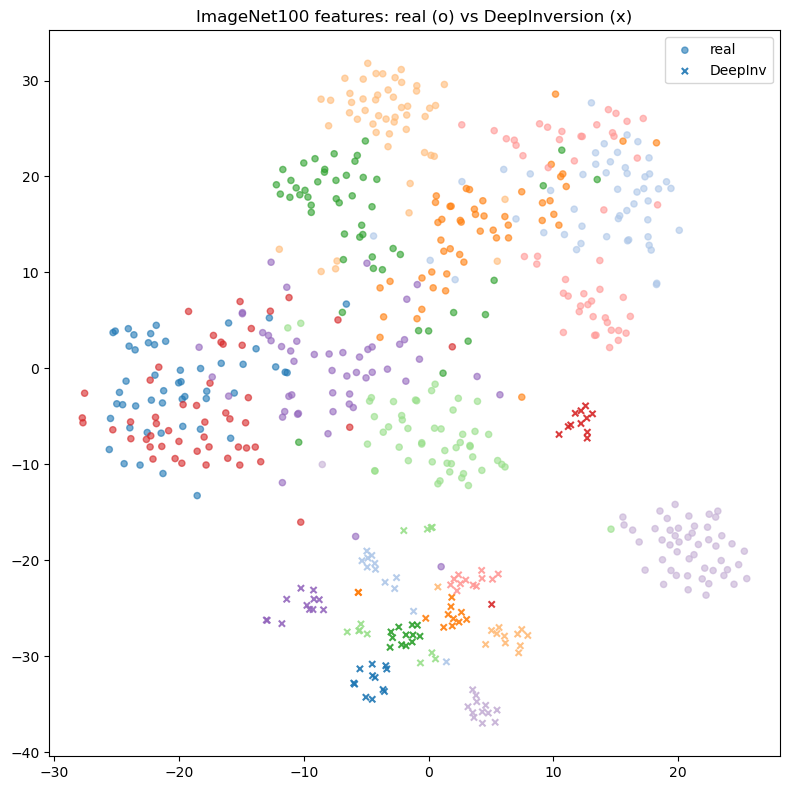

In [55]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, init="random", random_state=0)
Z = tsne.fit_transform(X)   # (N_total, 2)

unique_classes = np.unique(y_cls)
cmap = plt.get_cmap("tab20")
class2color = {c: cmap(i % 20) for i, c in enumerate(unique_classes)}

plt.figure(figsize=(8, 8))
for dom, marker, alpha, label in [
    (0, "o", 0.6, "real"),
    (1, "x", 0.9, "DeepInv"),
]:
    idx = (y_dom == dom)
    colors = [class2color[c] for c in y_cls[idx]]
    plt.scatter(
        Z[idx, 0], Z[idx, 1],
        c=colors, marker=marker, alpha=alpha, s=20, label=label
    )

plt.legend()
plt.title("ImageNet100 features: real (o) vs DeepInversion (x)")
plt.tight_layout()
plt.show()


In [42]:
from torchvision import datasets, transforms

data_root = "/home/kouyou/datasets/ImageNet100/train/"   # ImageFolder 形式になっているディレクトリ

# DeepInversion で作ったクラスだけに絞る
classes_used = sorted(labels_di.unique().tolist())    # 例: [0..9]

# 画像の前処理（元画像 → tensor）
transform_raw = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),          # [0,1]
])

dataset = datasets.ImageFolder(data_root, transform=transform_raw)

# クラスごとに数枚ずつサンプル
imgs_real_list = []
labels_real_list = []

per_class = 500   # 1クラスあたり何枚にするか（お好みで）

count_per_class = {c: 0 for c in classes_used}
for img, label in dataset:
    if label not in classes_used:
        continue
    if count_per_class[label] >= per_class:
        continue
    imgs_real_list.append(img)
    labels_real_list.append(label)
    count_per_class[label] += 1
    if all(v >= per_class for v in count_per_class.values()):
        break

imgs_real = torch.stack(imgs_real_list, dim=0)   # (M, 3, H, W)
labels_real = torch.tensor(labels_real_list, dtype=torch.long)
print(imgs_real.shape, labels_real.shape)


torch.Size([5000, 3, 224, 224]) torch.Size([5000])


In [43]:
import torch.nn.functional as F

device = "cuda"

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

def normalize_batch(x):
    # x: (N,3,H,W) in [0,1]
    return (x - IMAGENET_MEAN.to(x.device)) / IMAGENET_STD.to(x.device)

def get_features(net, x, batch_size=64):
    """
    x: (N,3,H,W) on CPU, [0,1]
    return: (N, D) feature vectors
    """
    net.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, x.size(0), batch_size):
            xb = x[i:i+batch_size].to(device)
            xb = normalize_batch(xb)

            out = net(xb)              # or net._network(xb) etc.
            feat = out["features"]     # ここはあなたの実装に合わせて
            feat = feat.view(feat.size(0), -1)
            feats.append(feat.cpu())
    return torch.cat(feats, dim=0)      # (N, D)


In [44]:
# モデルを GPU へ
net = net.to(device)
net.eval()

# DeepInversion 画像の feature
feats_di = get_features(net, imgs_di)        # (N_di, D)

# 実画像の feature
feats_real = get_features(net, imgs_real)    # (N_real, D)

# ラベルを numpy に
y_di = labels_di.cpu().numpy()
y_real = labels_real.cpu().numpy()

# domain ラベル (0: real, 1: DeepInv)
import numpy as np
X = torch.cat([feats_real, feats_di], dim=0).numpy()   # (N_total, D)
y_cls = np.concatenate([y_real, y_di], axis=0)
y_dom = np.concatenate([np.zeros_like(y_real), np.ones_like(y_di)], axis=0)


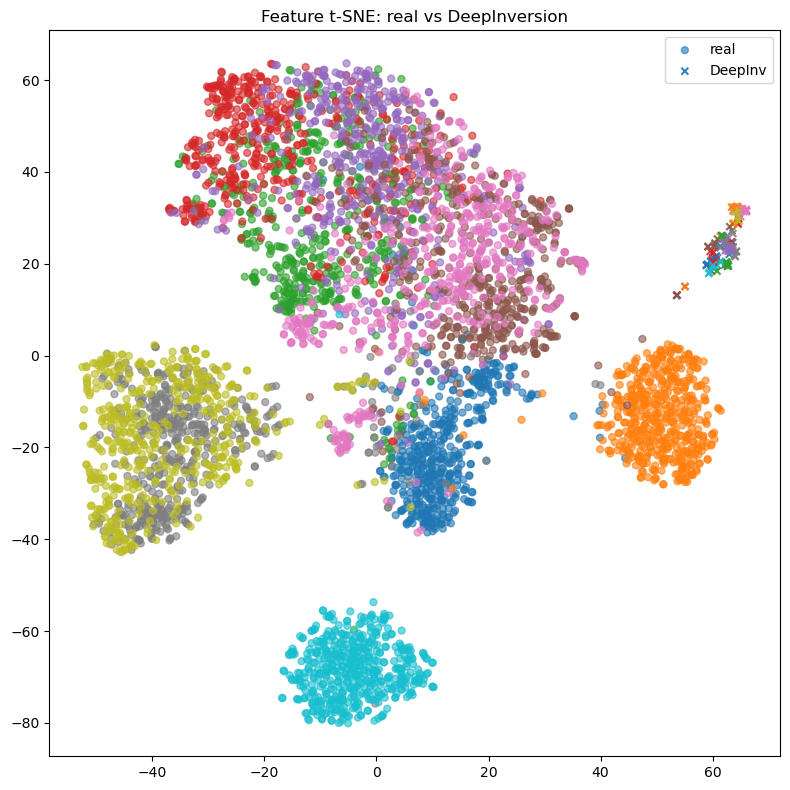

In [45]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, init="random", random_state=0)
Z = tsne.fit_transform(X)   # (N_total, 2)

# クラスごとに色、real/DeepInv でマーカーを変える
unique_classes = np.unique(y_cls)
cmap = plt.get_cmap("tab10")
class2color = {c: cmap(i % 10) for i, c in enumerate(unique_classes)}

plt.figure(figsize=(8, 8))

for dom, marker, alpha, label in [
    (0, "o", 0.6, "real"),
    (1, "x", 0.9, "DeepInv"),
]:
    idx = (y_dom == dom)
    colors = [class2color[c] for c in y_cls[idx]]
    plt.scatter(
        Z[idx, 0], Z[idx, 1],
        c=colors, marker=marker, alpha=alpha, s=25, label=label
    )

plt.legend()
plt.title("Feature t-SNE: real vs DeepInversion")
plt.tight_layout()
plt.show()
